In [1]:
# ============================================
# 1. Importación de librerías
# ============================================
import pandas as pd
import re
import matplotlib.pyplot as plt

# Configuración opcional
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ============================================
# 2. Carga de datos
# ============================================
fake_path = "Fake.csv"
true_path = "True.csv"

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)

print("Dimensiones Fake.csv:", df_fake.shape)
print("Dimensiones True.csv:", df_true.shape)

Dimensiones Fake.csv: (23481, 4)
Dimensiones True.csv: (21417, 4)


In [3]:
# ============================================
# 3. Inspección inicial
# ============================================
print("Columnas Fake:", df_fake.columns.tolist())
print("Columnas True:", df_true.columns.tolist())

print("\nPrimeras filas de Fake:")
display(df_fake.head())

print("\nPrimeras filas de True:")
display(df_true.head())

Columnas Fake: ['title', 'text', 'subject', 'date']
Columnas True: ['title', 'text', 'subject', 'date']

Primeras filas de Fake:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017"



Primeras filas de True:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for ...",politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian diplomat in May 2016 that Russi...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Service on Friday to charge “much mo...,politicsNews,"December 29, 2017"


In [4]:
# ============================================
# 4. Crear etiqueta de clase
#    1 = fake
#    0 = true
# ============================================
df_fake["label"] = 1
df_true["label"] = 0

print(df_fake["label"].value_counts())
print(df_true["label"].value_counts())

label
1    23481
Name: count, dtype: int64
label
0    21417
Name: count, dtype: int64


In [5]:
# ============================================
# 5. Unir ambos datasets
# ============================================
df = pd.concat([df_fake, df_true], ignore_index=True)

print("Dimensión total:", df.shape)
display(df.head())

Dimensión total: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017",1


In [6]:
# ============================================
# 6. Revisión de calidad de datos
# ============================================
print("Tipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nCantidad de registros por clase:")
display(df["label"].value_counts())

Tipos de datos:


title      object
text       object
subject    object
date       object
label       int64
dtype: object


Valores nulos por columna:


title      0
text       0
subject    0
date       0
label      0
dtype: int64


Cantidad de registros por clase:


label
1    23481
0    21417
Name: count, dtype: int64

In [7]:
# ============================================
# 7. Verificar textos vacíos o con espacios
# ============================================
# Convertimos a string por seguridad
df["title"] = df["title"].astype(str)
df["text"] = df["text"].astype(str)
df["subject"] = df["subject"].astype(str)
df["date"] = df["date"].astype(str)

empty_title = (df["title"].str.strip() == "").sum()
empty_text = (df["text"].str.strip() == "").sum()

print(f"Títulos vacíos: {empty_title}")
print(f"Textos vacíos: {empty_text}")

print("\nTextos vacíos por clase:")
display(df[df["text"].str.strip() == ""]["label"].value_counts())

Títulos vacíos: 0
Textos vacíos: 631

Textos vacíos por clase:


label
1    630
0      1
Name: count, dtype: int64

In [8]:
# ============================================
# 8. Revisar duplicados
# ============================================
duplicados_exactos = df.duplicated().sum()
duplicados_title_text = df.duplicated(subset=["title", "text"]).sum()

print(f"Duplicados exactos: {duplicados_exactos}")
print(f"Duplicados por title + text: {duplicados_title_text}")

Duplicados exactos: 209
Duplicados por title + text: 5793


In [9]:
# ============================================
# 9. Revisar calidad de la columna date
# ============================================
df["date"] = df["date"].astype(str).str.strip()

# Para pandas 2.x
try:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")
except:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)

invalid_dates = df["date_parsed"].isnull().sum()

print(f"Fechas no convertibles: {invalid_dates}")

print("\nEjemplos de fechas inválidas:")
display(df[df["date_parsed"].isnull()][["date"]].drop_duplicates().head(20))

Fechas no convertibles: 10

Ejemplos de fechas inválidas:


,date
9358,https://100percentfedup.com/served-roy-moore-vietnamletter-veteran-sets-record-straight-honorable-decent-respectable...
15507,https://100percentfedup.com/video-hillary-asked-about-trump-i-just-want-to-eat-some-pie/
15508,https://100percentfedup.com/12-yr-old-black-conservative-whose-video-to-obama-went-viral-do-you-really-love-america-...
15839,https://fedup.wpengine.com/wp-content/uploads/2015/04/hillarystreetart.jpg
15840,https://fedup.wpengine.com/wp-content/uploads/2015/04/entitled.jpg
18933,MSNBC HOST Rudely Assumes Steel Worker Would Never Let His Son Follow in His Footsteps…He Couldn’t Be More Wrong [Vi...


In [10]:
# ============================================
# 10. Revisar distribución de subject
# ============================================
print("Valores únicos en subject:")
display(df["subject"].value_counts().head(20))

print("\nDistribución de subject por clase:")
display(pd.crosstab(df["subject"], df["label"]).head(20))

Valores únicos en subject:


subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


Distribución de subject por clase:


label,0,1
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6841
politicsNews,11272,0
worldnews,10145,0


In [11]:
# ============================================
# 11. Longitud de títulos y textos
# ============================================
df["title_len"] = df["title"].apply(lambda x: len(x.split()))
df["text_len"] = df["text"].apply(lambda x: len(x.split()))

print("Resumen longitud de títulos:")
display(df["title_len"].describe())

print("\nResumen longitud de textos:")
display(df["text_len"].describe())

Resumen longitud de títulos:


count    44898.000000
mean        12.453472
std          4.111476
min          1.000000
25%         10.000000
50%         11.000000
75%         14.000000
max         42.000000
Name: title_len, dtype: float64


Resumen longitud de textos:


count    44898.000000
mean       405.282284
std        351.265595
min          0.000000
25%        203.000000
50%        362.000000
75%        513.000000
max       8135.000000
Name: text_len, dtype: float64

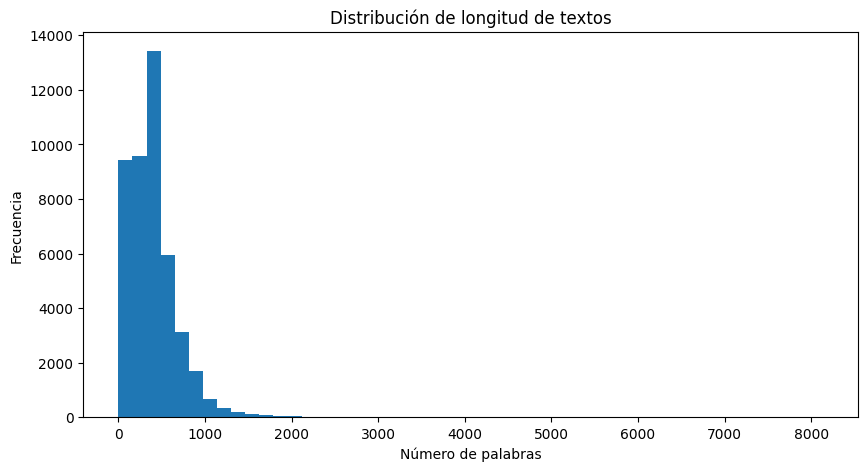

In [12]:
# ============================================
# 12. Visualización simple de longitudes
# ============================================
plt.figure(figsize=(10, 5))
plt.hist(df["text_len"], bins=50)
plt.title("Distribución de longitud de textos")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación:** La mayoría de las noticias se concentra en longitudes bajas y medias, mientras que pocas presentan textos extremadamente largos. Esto evidencia una distribución sesgada a la derecha y justifica limitar la longitud máxima del texto en la etapa de modelado.

In [13]:
# ============================================
# 13. Limpieza inicial
# ============================================
# 13.1 Eliminar textos vacíos
df_clean = df[df["text"].str.strip() != ""].copy()

print("Después de eliminar textos vacíos:", df_clean.shape)

Después de eliminar textos vacíos: (44267, 8)


In [14]:
# ============================================
# 14. Eliminar duplicados por title + text
# ============================================
antes = df_clean.shape[0]

df_clean = df_clean.drop_duplicates(subset=["title", "text"]).copy()

despues = df_clean.shape[0]
eliminados = antes - despues

print(f"Registros antes: {antes}")
print(f"Registros después: {despues}")
print(f"Duplicados eliminados: {eliminados}")

Registros antes: 44267
Registros después: 38658
Duplicados eliminados: 5609


In [15]:
# ============================================
# 15. Limpieza básica de texto
# ============================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+", " ", text)   # eliminar URLs
    text = re.sub(r"[^a-zA-Z\\s]", " ", text)       # dejar solo letras y espacios
    text = re.sub(r"\\s+", " ", text).strip()       # eliminar espacios extra
    return text

df_clean["title_clean"] = df_clean["title"].apply(clean_text)
df_clean["text_clean"] = df_clean["text"].apply(clean_text)

display(df_clean[["title", "title_clean", "text", "text_clean"]].head(3))

,title,title_clean,text,text_clean
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,donald trump sends out embarrassing new year s eve message this is disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout...
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,drunk bragging trump staffer started russian collusion investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like m...
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,sheriff david clarke becomes an internet joke for threatening to poke people in the eye,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",on friday it was revealed that former milwaukee sheriff david clarke who was being considered for homeland securit...


In [16]:
# ============================================
# 16. Revisar columnas limpias por separado
# ============================================
display(df_clean[["title_clean", "text_clean", "date_parsed"]].head(3))

,title_clean,text_clean,date_parsed
0,donald trump sends out embarrassing new year s eve message this is disturbing,donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout...,2017-12-31
1,drunk bragging trump staffer started russian collusion investigation,house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like m...,2017-12-31
2,sheriff david clarke becomes an internet joke for threatening to poke people in the eye,on friday it was revealed that former milwaukee sheriff david clarke who was being considered for homeland securit...,2017-12-30


In [17]:
# ============================================
# 17. Seleccionar columnas finales
# ============================================
# Nota:
# - subject se conserva para análisis descriptivo
# - date y date_parsed también se conservan por si luego quieres explorar tendencias temporales
# - title_clean y text_clean se mantienen por separado para el modelado posterior

df_final = df_clean[
    [
        "title",
        "text",
        "subject",
        "date",
        "title_clean",
        "text_clean",
        "date_parsed",
        "label"
    ]
].copy()

print("Dimensión final del dataset limpio:", df_final.shape)
display(df_final.head())

Dimensión final del dataset limpio: (38658, 8)


,title,text,subject,date,title_clean,text_clean,date_parsed,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017",donald trump sends out embarrassing new year s eve message this is disturbing,donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout...,2017-12-31,1
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017",drunk bragging trump staffer started russian collusion investigation,house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like m...,2017-12-31,1
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017",sheriff david clarke becomes an internet joke for threatening to poke people in the eye,on friday it was revealed that former milwaukee sheriff david clarke who was being considered for homeland securit...,2017-12-30,1
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017",trump is so obsessed he even has obama s name coded into his website images,on christmas day donald trump announced that he would be back to work the following day but he is golfing for th...,2017-12-29,1
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017",pope francis just called out donald trump during his christmas speech,pope francis used his annual christmas day message to rebuke donald trump without even mentioning his name the pope...,2017-12-25,1


In [18]:
# ============================================
# 18. Verificación final
# ============================================
print("Valores nulos por columna:")
display(df_final.isnull().sum())

print("\nDistribución final de clases:")
display(df_final["label"].value_counts())

print("\nProporción final de clases:")
display(df_final["label"].value_counts(normalize=True))

Valores nulos por columna:


title          0
text           0
subject        0
date           0
title_clean    0
text_clean     0
date_parsed    6
label          0
dtype: int64


Distribución final de clases:


label
0    21196
1    17462
Name: count, dtype: int64


Proporción final de clases:


label
0    0.548295
1    0.451705
Name: proportion, dtype: float64

In [19]:
# ============================================
# 19. Guardar dataset limpio
# ============================================
df_final.to_csv("Dataset_Limpio_Fake_News.csv", index=False)
print("Archivo guardado como: Dataset_Limpio_Fake_News.csv")

Archivo guardado como: Dataset_Limpio_Fake_News.csv


In [20]:
# ============================================
# 20. Resumen automático para el informe
# ============================================
resumen = {
    "Registros Fake originales": len(df_fake),
    "Registros True originales": len(df_true),
    "Total original": len(df),
    "Textos vacíos eliminados": (df["text"].str.strip() == "").sum(),
    "Duplicados eliminados (title+text)": eliminados,
    "Total final limpio": len(df_final)
}

resumen_df = pd.DataFrame(list(resumen.items()), columns=["Métrica", "Valor"])
display(resumen_df)

,Métrica,Valor
0,Registros Fake originales,23481
1,Registros True originales,21417
2,Total original,44898
3,Textos vacíos eliminados,631
4,Duplicados eliminados (title+text),5609
5,Total final limpio,38658


**Interpretación:** El proceso de limpieza redujo el conjunto de datos desde 44.898 a 38.658 registros, principalmente por la eliminación de textos vacíos y noticias duplicadas. Esto permitió obtener un dataset más consistente y adecuado para el análisis y el entrenamiento de modelos.

In [21]:
# ============================================
# 21. Preparación para análisis exploratorio
# ============================================
df_eda = df_final.copy()

# Crear variables auxiliares
df_eda["title_len"] = df_eda["title_clean"].apply(lambda x: len(str(x).split()))
df_eda["text_len"] = df_eda["text_clean"].apply(lambda x: len(str(x).split()))
df_eda["title_char_len"] = df_eda["title_clean"].apply(lambda x: len(str(x)))
df_eda["text_char_len"] = df_eda["text_clean"].apply(lambda x: len(str(x)))

# Subconjunto con fechas válidas para análisis temporal
df_dates = df_eda[df_eda["date_parsed"].notnull()].copy()
df_dates["year"] = df_dates["date_parsed"].dt.year
df_dates["month"] = df_dates["date_parsed"].dt.month
df_dates["year_month"] = df_dates["date_parsed"].dt.to_period("M").astype(str)

print("Dimensión de df_eda:", df_eda.shape)
print("Registros con fecha válida:", df_dates.shape[0])

Dimensión de df_eda: (38658, 12)
Registros con fecha válida: 38652


In [22]:
# ============================================
# 22. Estadística descriptiva general
# ============================================
print("Resumen estadístico de variables numéricas:")
display(
    df_eda[["title_len", "text_len", "title_char_len", "text_char_len"]].describe()
)

Resumen estadístico de variables numéricas:


,title_len,text_len,title_char_len,text_char_len
count,38658.000000,38658.000000,38658.000000,38658.000000
mean,12.451963,408.421776,76.107300,2454.208081
std,3.895156,319.216064,21.945306,1936.865674
min,1.000000,1.000000,8.000000,4.000000
25%,10.000000,219.000000,62.000000,1316.000000
50%,12.000000,374.000000,71.000000,2226.000000
75%,14.000000,518.000000,85.000000,3095.000000
max,44.000000,8281.000000,279.000000,51793.000000


Frecuencia de clases:


label
0    21196
1    17462
Name: count, dtype: int64


Proporción de clases:


label
0    0.548295
1    0.451705
Name: proportion, dtype: float64

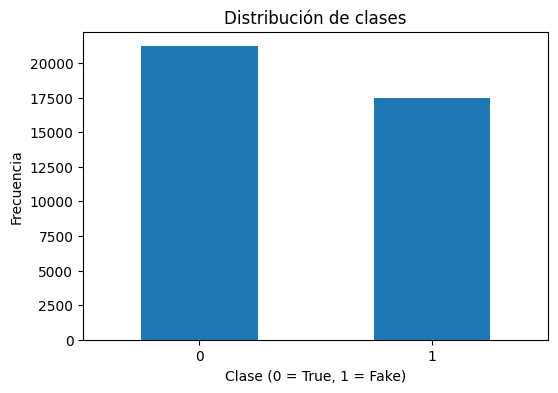

In [23]:
# ============================================
# 23. Distribución de clases
# ============================================
print("Frecuencia de clases:")
display(df_eda["label"].value_counts())

print("\nProporción de clases:")
display(df_eda["label"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
df_eda["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase (0 = True, 1 = Fake)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

**Interpretación:** La distribución de clases muestra un ligero predominio de noticias reales (54.83%) frente a noticias falsas (45.17%). Aunque no existe un desbalance severo, esta diferencia justifica mantener particiones estratificadas y considerar métricas como precisión, recall y F1-score durante el modelado.

Frecuencia de subject:


subject
politicsNews       11216
worldnews           9980
News                9050
politics            6430
US_News              783
left-news            684
Government News      515
Name: count, dtype: int64

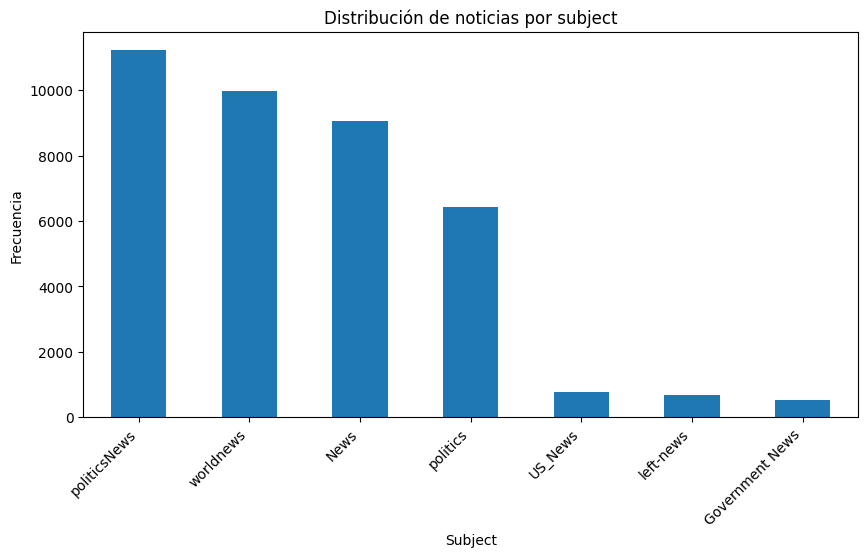

In [24]:
# ============================================
# 24. Distribución de subject
# ============================================
print("Frecuencia de subject:")
display(df_eda["subject"].value_counts())

plt.figure(figsize=(10, 5))
df_eda["subject"].value_counts().plot(kind="bar")
plt.title("Distribución de noticias por subject")
plt.xlabel("Subject")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretación:** La distribución por *subject* evidencia que las categorías de política y noticias internacionales concentran la mayor parte del dataset. Esto sugiere que el problema de detección de fake news está fuertemente orientado al dominio político, donde suele existir mayor presencia de desinformación.

Distribución de subject por clase:


label,0,1
subject,,
Government News,0,515
News,0,9050
US_News,0,783
left-news,0,684
politics,0,6430
politicsNews,11216,0
worldnews,9980,0


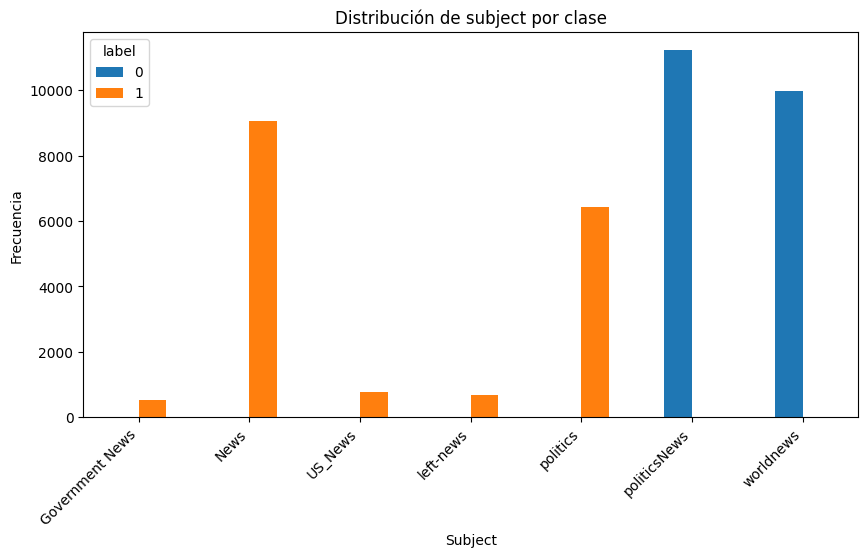

In [25]:
# ============================================
# 25. Subject por clase
# ============================================
subject_label = pd.crosstab(df_eda["subject"], df_eda["label"])

print("Distribución de subject por clase:")
display(subject_label)

subject_label.plot(kind="bar", figsize=(10, 5))
plt.title("Distribución de subject por clase")
plt.xlabel("Subject")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.legend(title="label")
plt.show()

**Interpretación:** Se observa una separación casi perfecta entre las categorías *subject* y la clase objetivo, ya que algunos *subjects* aparecen únicamente en noticias reales y otros solo en noticias falsas. Esto sugiere que esta variable podría introducir sesgo o fuga de información, por lo que debe analizarse con cautela en el modelado.

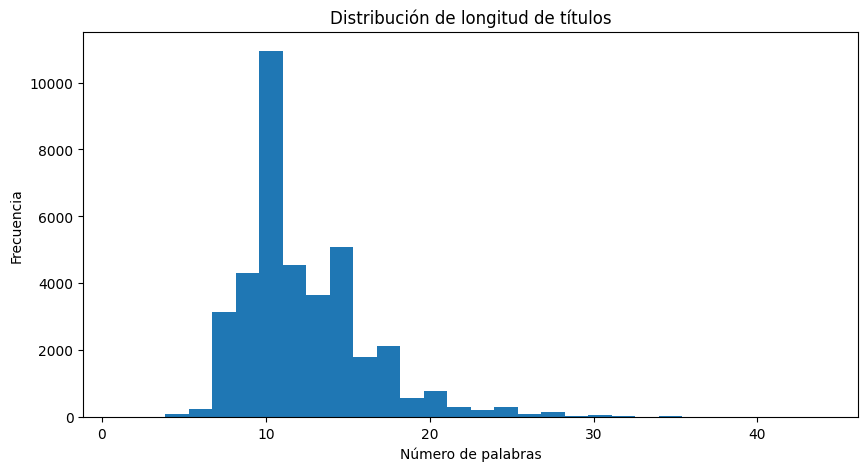

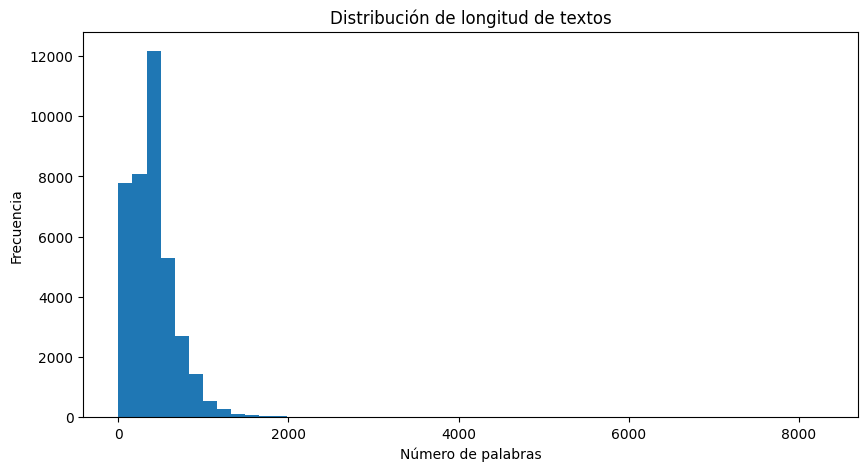

In [26]:
# ============================================
# 26. Histogramas de longitud de títulos y textos
# ============================================
plt.figure(figsize=(10, 5))
plt.hist(df_eda["title_len"], bins=30)
plt.title("Distribución de longitud de títulos")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df_eda["text_len"], bins=50)
plt.title("Distribución de longitud de textos")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación:** Los títulos presentan una longitud relativamente estable, concentrándose principalmente entre 8 y 15 palabras, mientras que los textos muestran una mayor dispersión y una fuerte asimetría positiva, con algunos casos extremadamente largos. Esto confirma que los títulos son más homogéneos y que los cuerpos de noticia requieren estrategias de truncamiento para el modelado.

Promedio de longitud por clase:


,title_len,text_len,title_char_len,text_char_len
label,,,,
0,10.408473,387.448575,64.572891,2376.066380
1,14.932425,433.879796,90.108178,2549.059272


<Figure size 800x500 with 0 Axes>

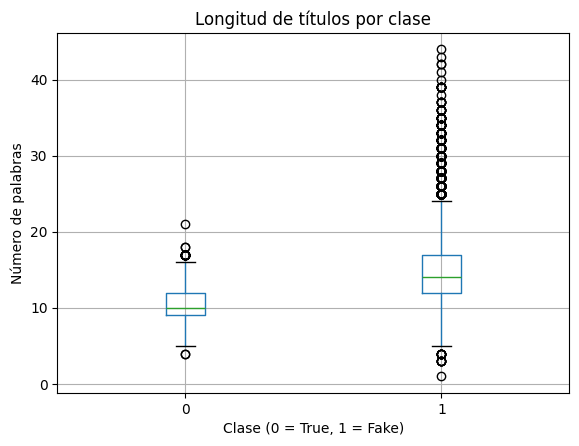

<Figure size 800x500 with 0 Axes>

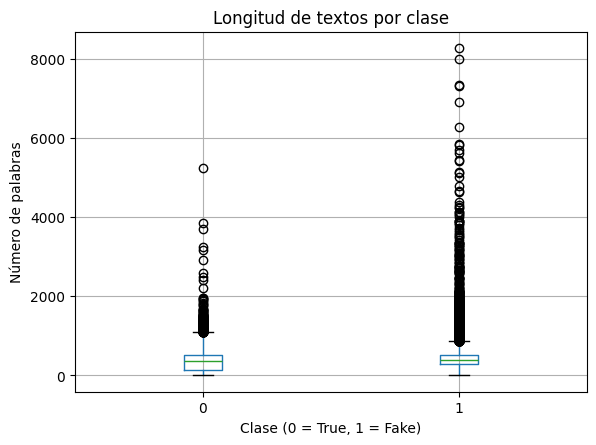

In [27]:
# ============================================
# 27. Comparación de longitud por clase
# ============================================
print("Promedio de longitud por clase:")
display(
    df_eda.groupby("label")[["title_len", "text_len", "title_char_len", "text_char_len"]].mean()
)

plt.figure(figsize=(8, 5))
df_eda.boxplot(column="title_len", by="label")
plt.title("Longitud de títulos por clase")
plt.suptitle("")
plt.xlabel("Clase (0 = True, 1 = Fake)")
plt.ylabel("Número de palabras")
plt.show()

plt.figure(figsize=(8, 5))
df_eda.boxplot(column="text_len", by="label")
plt.title("Longitud de textos por clase")
plt.suptitle("")
plt.xlabel("Clase (0 = True, 1 = Fake)")
plt.ylabel("Número de palabras")
plt.show()

**Interpretación:** Las noticias falsas presentan, en promedio, títulos y textos más largos que las noticias reales. Esta diferencia también se observa en los diagramas de caja, donde la clase *Fake* muestra medianas superiores y una mayor dispersión, lo que sugiere que la longitud del contenido podría aportar información útil en la detección de fake news.

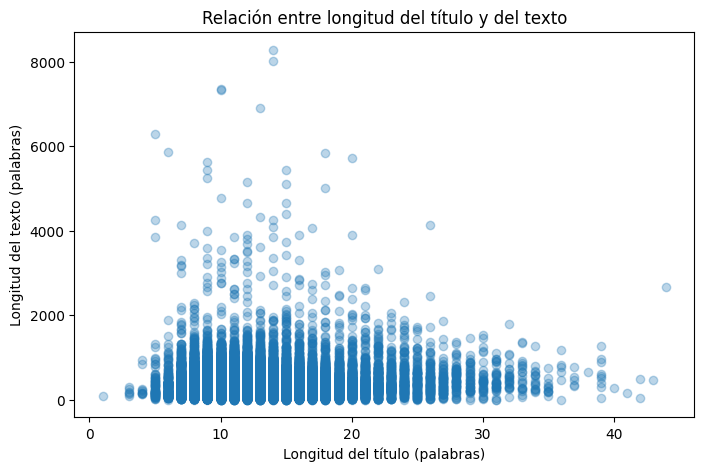

In [28]:
# ============================================
# 28. Relación entre longitud de título y texto
# ============================================
plt.figure(figsize=(8, 5))
plt.scatter(df_eda["title_len"], df_eda["text_len"], alpha=0.3)
plt.title("Relación entre longitud del título y del texto")
plt.xlabel("Longitud del título (palabras)")
plt.ylabel("Longitud del texto (palabras)")
plt.show()

**Interpretación:** La relación entre la longitud del título y la del texto no muestra una tendencia lineal fuerte, ya que para un mismo tamaño de título existen textos con longitudes muy variadas. Esto sugiere que ambas variables aportan información complementaria y no dependen directamente entre sí.

Matriz de correlación:


,title_len,text_len,title_char_len,text_char_len
title_len,1.000000,0.057903,0.923955,0.036995
text_len,0.057903,1.000000,0.051978,0.996867
title_char_len,0.923955,0.051978,1.000000,0.036036
text_char_len,0.036995,0.996867,0.036036,1.000000


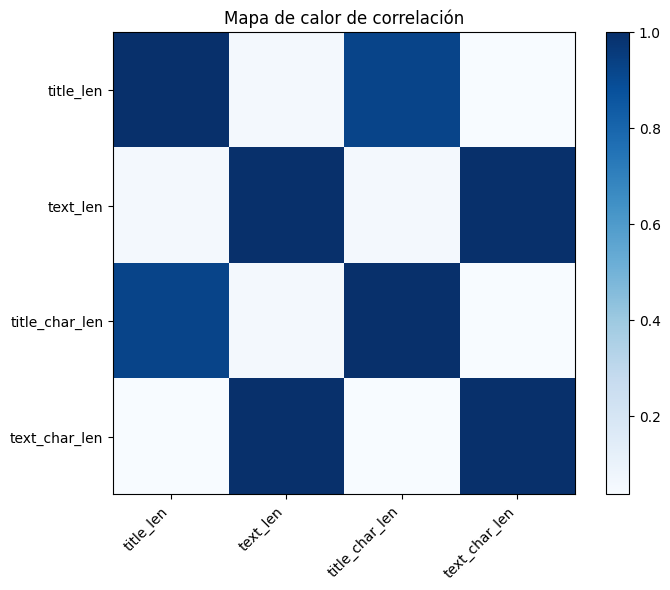

In [29]:
# ============================================
# 29. Correlación entre variables numéricas
# ============================================
corr = df_eda[["title_len", "text_len", "title_char_len", "text_char_len"]].corr()

print("Matriz de correlación:")
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="Blues", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Mapa de calor de correlación")
plt.show()

**Interpretación:** Se observa una alta correlación entre las variables de longitud en palabras y caracteres dentro del mismo campo (título o texto), lo cual es esperado. En contraste, la correlación entre título y texto es baja, indicando que ambas dimensiones capturan información diferente y complementaria.

In [30]:
# ============================================
# 30. Detección simple de valores atípicos
# ============================================
Q1 = df_eda["text_len"].quantile(0.25)
Q3 = df_eda["text_len"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_text = df_eda[(df_eda["text_len"] < lower_bound) | (df_eda["text_len"] > upper_bound)]

print("Cantidad de valores atípicos en text_len:", len(outliers_text))
display(outliers_text[["title", "text_len", "label"]].head(10))

Cantidad de valores atípicos en text_len: 1359


,title,text_len,label
65,Principles Over Power: Why Republicans Need To Do What’s Right To Remain Relevant,1244,1
616,10 Reasons Donald Trump And Kim Jong-Un Are Basically The Same Person,1034,1
1057,Dear Democrats: Throwing Nancy Pelosi Under The Bus Is Not The Answer (VIDEO),1075,1
1162,How The GOP Became The Party Of White Supremacists Under Donald Trump,1301,1
1350,"Dear President Moron: Since You Don’t Seem To Get How NATO Works, Please Allow Me To Educate You",1414,1
1717,"Chaffetz’s Decision To Quit Means Big Trouble For Trump, And Here’s Exactly How",969,1
2611,Twitter TRASHES Draft Dodger Donald Trump After Disgusting Attack On John McCain (TWEETS),1065,1
2639,Trump’s List Of ‘Unreported Terror Attacks’ Appears To Have Been Written By Drunk Monkeys,1793,1
2734,Staffers INSIDE The White House Are Showing Us Just How MASSIVE An A** Trump Really Is (TWEETS),1034,1
2780,CEO Of Starbucks Sends Giant F**K YOU To Trump In Groundbreaking Open Letter,1334,1


**Interpretación:** Se identificaron 1,359 valores atípicos en la longitud de los textos, correspondientes a noticias significativamente más extensas que la mayoría del dataset. Estos casos no necesariamente representan errores, pero justifican el uso de truncamiento para controlar la variabilidad durante el modelado.

Frecuencia de noticias por año:


year
2015     1598
2016    13915
2017    23104
2018       35
Name: count, dtype: int64

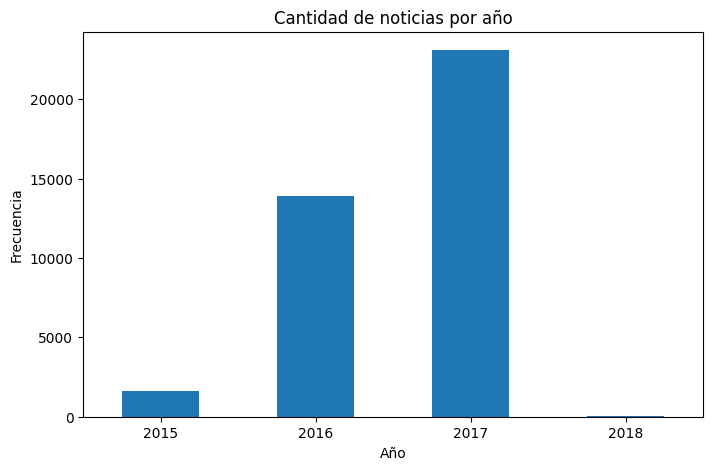

In [31]:
# ============================================
# 31. Distribución temporal por año
# ============================================
print("Frecuencia de noticias por año:")
display(df_dates["year"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
df_dates["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de noticias por año")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

**Interpretación:** La mayor concentración de noticias se encuentra en los años 2016 y 2017, mientras que 2015 y 2018 presentan una participación mucho menor. Esto indica que el dataset está temporalmente centrado en un periodo específico, lo cual puede influir en los patrones temáticos aprendidos por los modelos.

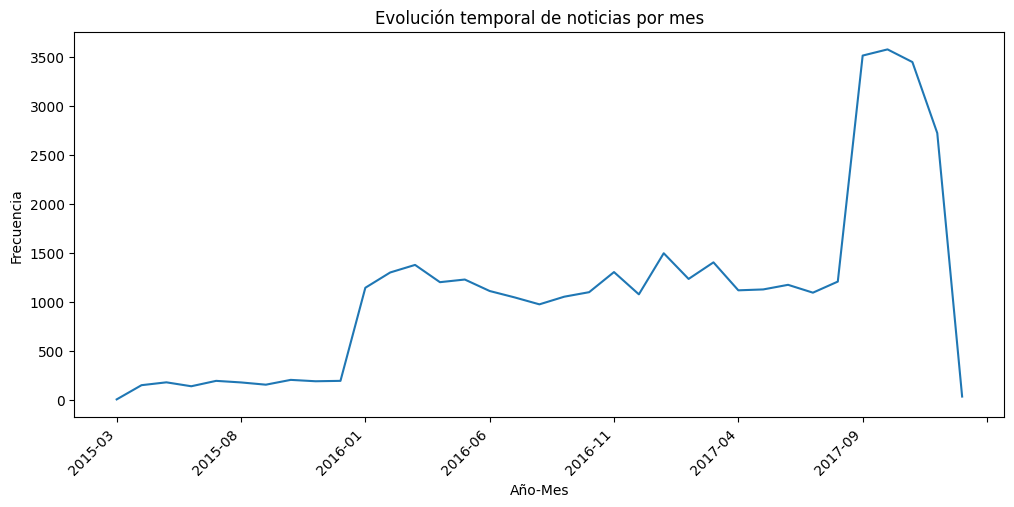

In [32]:
# ============================================
# 32. Evolución temporal por mes
# ============================================
monthly_counts = df_dates["year_month"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
monthly_counts.plot(kind="line")
plt.title("Evolución temporal de noticias por mes")
plt.xlabel("Año-Mes")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretación:** La evolución mensual evidencia un incremento progresivo en la cantidad de noticias, con picos marcados hacia finales de 2017. Esto sugiere una mayor actividad informativa en ese periodo, lo que puede influir en la distribución temática y temporal del dataset.

label,0,1
year_month,,
2015-03,0,6
2015-04,0,151
2015-05,0,180
2015-06,0,140
2015-07,0,195


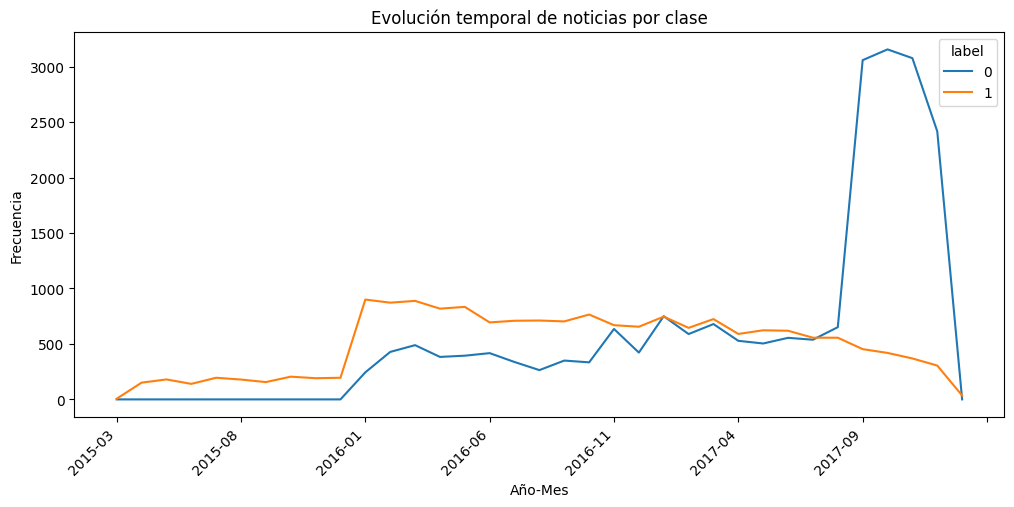

In [33]:
# ============================================
# 33. Evolución temporal por clase
# ============================================
monthly_class = pd.crosstab(df_dates["year_month"], df_dates["label"])

display(monthly_class.head())

monthly_class.plot(figsize=(12, 5))
plt.title("Evolución temporal de noticias por clase")
plt.xlabel("Año-Mes")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretación:** La evolución temporal por clase muestra que, en los primeros periodos, predominan las noticias falsas, mientras que hacia finales de 2017 aumenta considerablemente la cantidad de noticias reales. Esto evidencia cambios en la composición temporal del dataset y sugiere posibles variaciones temáticas según el periodo analizado.

In [34]:
# ============================================
# 34. Tabla resumen para el informe
# ============================================
eda_summary = {
    "Total de registros analizados": len(df_eda),
    "Noticias verdaderas (label=0)": int((df_eda["label"] == 0).sum()),
    "Noticias falsas (label=1)": int((df_eda["label"] == 1).sum()),
    "Cantidad de subjects": df_eda["subject"].nunique(),
    "Promedio de palabras en títulos": round(df_eda["title_len"].mean(), 2),
    "Promedio de palabras en textos": round(df_eda["text_len"].mean(), 2),
    "Máximo de palabras en títulos": int(df_eda["title_len"].max()),
    "Máximo de palabras en textos": int(df_eda["text_len"].max()),
    "Registros con fecha válida": int(df_dates.shape[0])
}

eda_summary_df = pd.DataFrame(list(eda_summary.items()), columns=["Indicador", "Valor"])
display(eda_summary_df)

,Indicador,Valor
0,Total de registros analizados,38658.00
1,Noticias verdaderas (label=0),21196.00
2,Noticias falsas (label=1),17462.00
3,Cantidad de subjects,7.00
4,Promedio de palabras en títulos,12.45
5,Promedio de palabras en textos,408.42
6,Máximo de palabras en títulos,44.00
7,Máximo de palabras en textos,8281.00
8,Registros con fecha válida,38652.00


In [35]:
# ============================================
# 35. Selección de variables de entrada
# ============================================
X_title = df_final["title_clean"]
X_text = df_final["text_clean"]
y = df_final["label"]

print("Número de registros:", len(y))
print("\nDistribución de clases:")
display(y.value_counts())

Número de registros: 38658

Distribución de clases:


label
0    21196
1    17462
Name: count, dtype: int64